In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

device = torch.device("cpu")  

In [2]:
df = pd.read_csv('data/14-global_active_power.csv')

print('Number of rows and columns:', df.shape)
df.head(5)

Number of rows and columns: (2049280, 7)


,date_time,Global_active_power,year,quarter,month,day,weekday
0,2006-12-16 17:24:00,4.216,2006,4,12,16,0
1,2006-12-16 17:25:00,5.360,2006,4,12,16,0
2,2006-12-16 17:26:00,5.374,2006,4,12,16,0
3,2006-12-16 17:27:00,5.388,2006,4,12,16,0
4,2006-12-16 17:28:00,3.666,2006,4,12,16,0


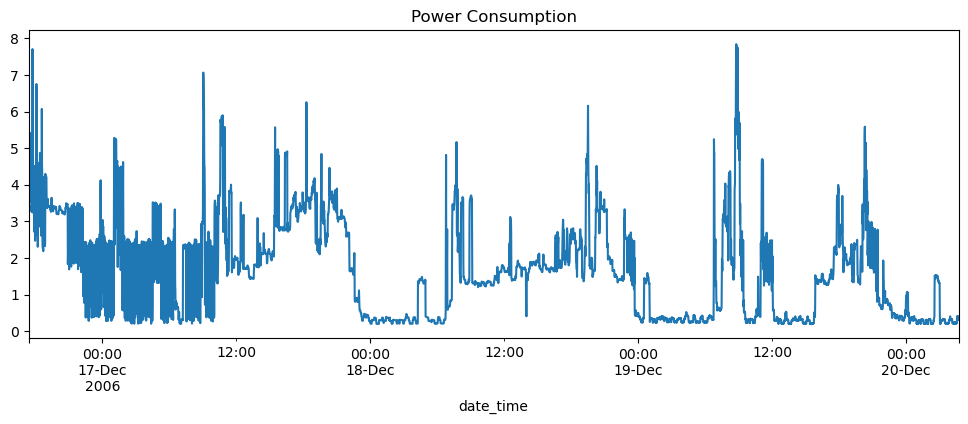

In [3]:
df['date_time'] = pd.to_datetime(df['date_time'])
df = df.set_index('date_time')

df = df[['Global_active_power']].dropna().iloc[:5000]

df['Global_active_power'].plot(figsize=(12,4), title="Power Consumption")
plt.show()

## Preprocessing

In [4]:
scaler = MinMaxScaler()
data = scaler.fit_transform(df)

In [5]:
def create_dataset(data, look_back=20):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

look_back = 20
X, y = create_dataset(data, look_back)

## Train/Test Split

In [6]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

## LSTM Model

In [7]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

In [8]:
# Data loader (for stability)
batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=batch_size,
    shuffle=False
)

In [9]:
# Define LSTM Model
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

In [10]:
# Initialize Model
model_lstm = LSTMModel().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

In [11]:
# Training Loop
epochs = 5

for epoch in range(epochs):
    model_lstm.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        output = model_lstm(X_batch)
        loss = criterion(output, y_batch)
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    print(f"LSTM Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.5f}")

LSTM Epoch 1, Loss: 0.01904
LSTM Epoch 2, Loss: 0.00704
LSTM Epoch 3, Loss: 0.00616
LSTM Epoch 4, Loss: 0.00599
LSTM Epoch 5, Loss: 0.00572


In [12]:
# Evaluation
def predict(model, loader):
    model.eval()
    preds = []
    
    with torch.no_grad():
        for X_batch, _ in loader:
            out = model(X_batch)
            preds.append(out.numpy())
    
    return np.vstack(preds)

pred_lstm = predict(model_lstm, test_loader)

pred_lstm = scaler.inverse_transform(pred_lstm)
y_test_inv = scaler.inverse_transform(y_test)

In [13]:
# Metrics
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, pred_lstm))
print("LSTM RMSE:", rmse_lstm)

LSTM RMSE: 0.25578007482558346


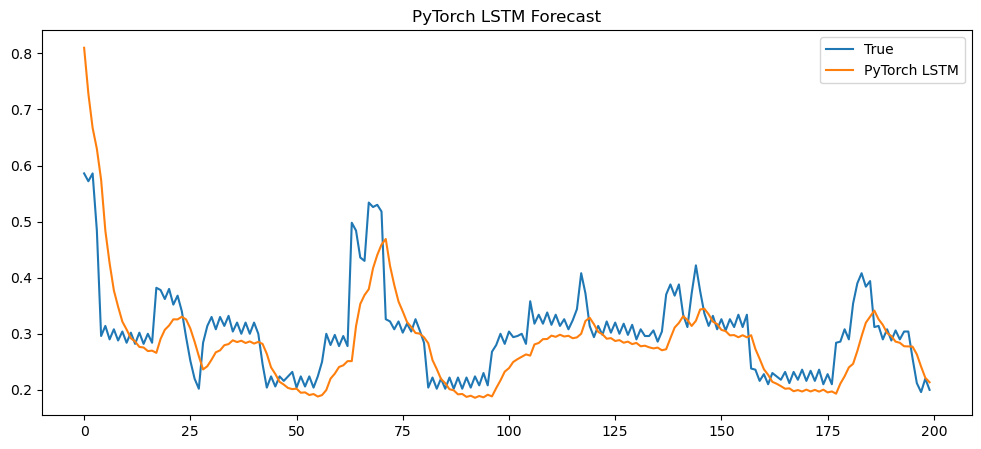

In [14]:
# Visualization
plt.figure(figsize=(12,5))
plt.plot(y_test_inv[:200], label="True")
plt.plot(pred_lstm[:200], label="PyTorch LSTM")
plt.legend()
plt.title("PyTorch LSTM Forecast")
plt.show()

## Minimal Transformer for Time Series

In [15]:
# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        
        div = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0)/d_model))
        
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [16]:
# Transformer Model
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.input_proj = nn.Linear(1, 16)
        self.pos = PositionalEncoding(16)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=16,
            nhead=2,
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc = nn.Linear(16, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        
        x = self.transformer(x)
        x = x[:, -1, :]
        
        return self.fc(x)

In [17]:
# Initialize Model
model_tf = TransformerModel().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_tf.parameters(), lr=0.001)

In [18]:
# Training Loop
for epoch in range(5):
    model_tf.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        output = model_tf(X_batch)
        loss = criterion(output, y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Transformer Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.5f}")

Transformer Epoch 1, Loss: 0.04401
Transformer Epoch 2, Loss: 0.00773
Transformer Epoch 3, Loss: 0.00671
Transformer Epoch 4, Loss: 0.00621
Transformer Epoch 5, Loss: 0.00632


In [19]:
# Evaluation
pred_tf = predict(model_tf, test_loader)

pred_tf = scaler.inverse_transform(pred_tf)

In [20]:
# Metrics
rmse_tf = np.sqrt(mean_squared_error(y_test_inv, pred_tf))
print("Transformer RMSE:", rmse_tf)

Transformer RMSE: 0.2649068488385627


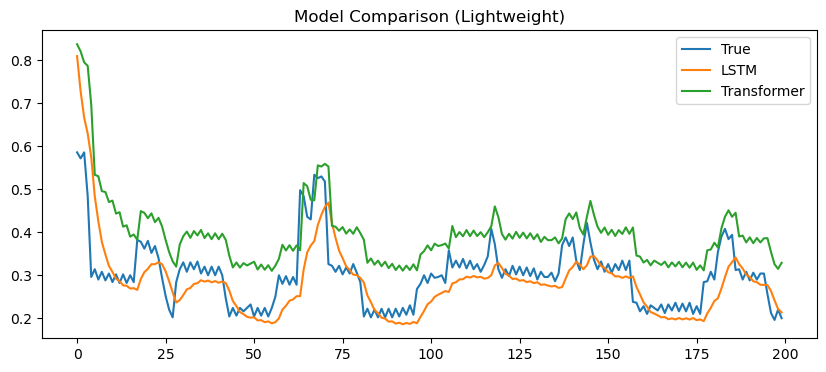

In [21]:
# Comparison Plot
plt.figure(figsize=(10,4))

plt.plot(y_test_inv[:200], label="True")
plt.plot(pred_lstm[:200], label="LSTM")
plt.plot(pred_tf[:200], label="Transformer")

plt.legend()
plt.title("Model Comparison (Lightweight)")
plt.show()